<a href="https://colab.research.google.com/github/FarsusDasdana/WorldCup_EloRating/blob/main/EloRating.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Understanding the Elo Formula

The formula `1 / (1 + 10 ** ((rating_b - rating_a) / 400))` is a logistic function. Here is why it is designed this way:

### 1. Why use `1 / (1 + ...)`?
This structure is a **Logistic Curve**. It ensures that the result is always between **0 and 1**.
- As the denominator gets very large, the result approaches 0.
- As the denominator gets close to 1, the result approaches 1.
This is perfect for representing a **probability** (0% to 100%).

### 2. Why `(1 + 10 ** x)`?
The use of **base 10** is a convention established by Arpad Elo.
- If two teams have the same rating ($R_B - R_A = 0$), the formula becomes $1 / (1 + 10^0)$, which is $1 / (1 + 1)$, or **0.5 (50%)**. This correctly predicts that equal teams have an equal chance of winning.

### 3. Why the `400` in `(rating_b - rating_a) / 400`?
The number **400** is a scaling factor that determines the "spread" of the ratings.
- It defines that a **400-point difference** makes the stronger team **10 times** more likely to win than the weaker team ($1 / (1 + 10^{-1}) \approx 0.91$).
- If you used a smaller number (like 100), ratings would be much more volatile. If you used a larger number, ratings would move very slowly.

### 4. Why is the default K-factor 32?
The **K-factor** is the maximum possible adjustment per game. It acts as the "learning rate" of the system.
- **K=32** is the historical standard for established players. It is high enough to allow ratings to reflect recent form but low enough to prevent a single "fluke" result from causing an extreme rank shift. Higher K-factors (like 40 or 60) are often used for high-stakes tournament matches to make them more impactful.

# Elo Rating System for 2026 World Cup

This notebook demonstrates the Elo rating system, which calculates relative skill levels in zero-sum games.

In [1]:
def calculate_elo(rating_a, rating_b, result_for_a, k_factor=32, name_a="", name_b=""):
    """
    Calculates the new Elo ratings for two players/teams.

    Args:
        rating_a: Current rating of Team A
        rating_b: Current rating of Team B
        result_for_a: Result for Team A (1 for win, 0.5 for draw, 0 for loss)
        k_factor: The maximum possible adjustment per game
        name_a: Name of Team A (optional)
        name_b: Name of Team B (optional)

    Returns:
        new_rating_a: New rating for Team A
        new_rating_b: New rating for Team B
    """
    # 1. Calculate Expected Score for Team A (winning chance of team A)
    expected_a = 1 / (1 + 10 ** ((rating_b - rating_a) / 400))
    if name_a != "":
      print(f"Winning chance of {name_a}: {expected_a:.2%}")
    else:
      print(f"Winning chance of Team A: {expected_a:.2%}")
    # 2. Calculate Expected Score for Team B (winning chance of team B)
    expected_b = 1 - expected_a
    if name_b != "":
      print(f"Winning chance of {name_b}: {expected_b:.2%}")
    else:
      print(f"Winning chance of Team B: {expected_b:.2%}")

    # 3. Update Ratings
    new_rating_a = rating_a + k_factor * (result_for_a - expected_a)
    new_rating_b = rating_b + k_factor * ((1 - result_for_a) - expected_b)

    return round(new_rating_a), round(new_rating_b)

In [2]:
# Initialize team ratings
teams = {
    # Top 20 from recent ratings
    'Spain': 2157,
    'Argentina': 2115,
    'France': 2063,
    'England': 2024,
    'Brazil': 1991,
    'Portugal': 1989,
    'Colombia': 1982,
    'Netherlands': 1948,
    'Ecuador': 1938,
    'Germany': 1932,
    'Norway': 1914,
    'Croatia': 1912,
    'Turkey': 1911,
    'Japan': 1906,
    'Belgium': 1894,
    'Uruguay': 1892,
    'Switzerland': 1891,
    'Mexico': 1881,
    'Denmark': 1869,
    'Italy': 1869,
}

def play_match(team_a_name, team_b_name, score_a):
    rating_a = teams[team_a_name]
    rating_b = teams[team_b_name]

    new_a, new_b = calculate_elo(rating_a, rating_b, score_a, name_a=team_a_name, name_b=team_b_name)

    result_text = "Win" if score_a == 1 else "Draw" if score_a == 0.5 else "Loss"
    print(f"Match: {team_a_name} ({rating_a}) vs {team_b_name} ({rating_b}) -> {team_a_name} {result_text}")
    print(f"New Ratings: {team_a_name}: {new_a} ({new_a - rating_a:+}), {team_b_name}: {new_b} ({new_b - rating_b:+})\n")

    teams[team_a_name] = new_a
    teams[team_b_name] = new_b

print("--- Starting Tournament Demo ---\n")

# Scenario 1: Expected outcome (Higher rated France wins against Brazil)
play_match('France', 'Brazil', 1)

# Scenario 2: An upset (Lower rated Turkey wins against Portugal)
play_match('Turkey', 'Portugal', 1)

# Scenario 3: A draw between closely matched teams
play_match('Mexico', 'Turkey', 0.5)

--- Starting Tournament Demo ---

Winning chance of France: 60.22%
Winning chance of Brazil: 39.78%
Match: France (2063) vs Brazil (1991) -> France Win
New Ratings: France: 2076 (+13), Brazil: 1978 (-13)

Winning chance of Turkey: 38.96%
Winning chance of Portugal: 61.04%
Match: Turkey (1911) vs Portugal (1989) -> Turkey Win
New Ratings: Turkey: 1931 (+20), Portugal: 1969 (-20)

Winning chance of Mexico: 42.85%
Winning chance of Turkey: 57.15%
Match: Mexico (1881) vs Turkey (1931) -> Mexico Draw
New Ratings: Mexico: 1883 (+2), Turkey: 1929 (-2)



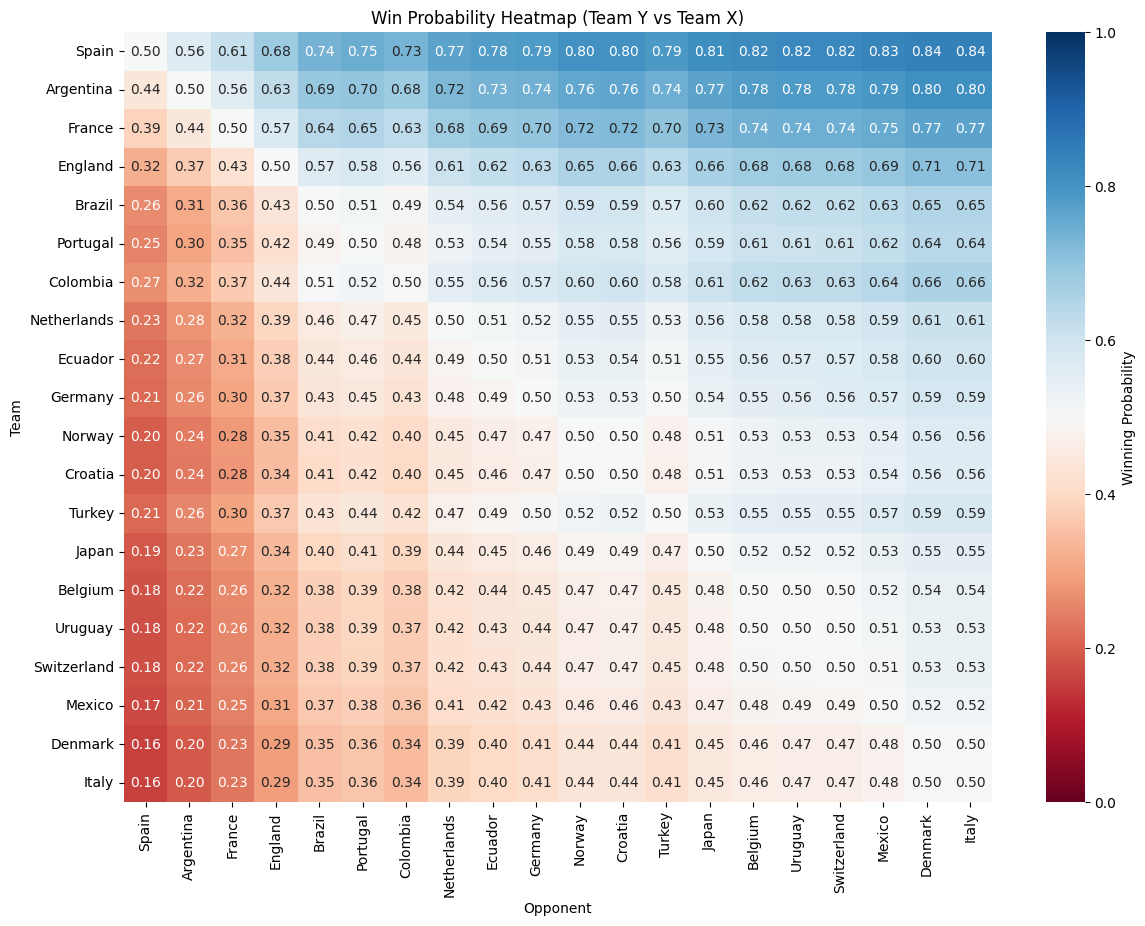

In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Create a list of team names
team_names = list(teams.keys())

# Initialize a matrix for win probabilities
n = len(team_names)
prob_matrix = np.zeros((n, n))

# Calculate n-to-n cross table
for i, team_a in enumerate(team_names):
    for j, team_b in enumerate(team_names):
        ra = teams[team_a]
        rb = teams[team_b]
        # Win probability formula
        prob_matrix[i, j] = 1 / (1 + 10 ** ((rb - ra) / 400))

# Create DataFrame for better visualization
df_probs = pd.DataFrame(prob_matrix, index=team_names, columns=team_names)

# Plotting the heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(
    df_probs,
    annot=True,
    fmt=".2f",
    cmap="RdBu",
    center=0.5,
    vmin=0,
    vmax=1,
    cbar_kws={'label': 'Winning Probability'}
)
plt.title("Win Probability Heatmap (Team Y vs Team X)")
plt.xlabel("Opponent")
plt.ylabel("Team")
plt.show()

# 2026 FIFA World Cup: Group Stage Probability Simulation

This section uses a **Monte Carlo simulation** (10,000 iterations per group) to predict the likelihood of each team's final standing. The match outcomes are derived from the **Elo winning probability formula**, with a slight adjustment to account for the possibility of draws.

In [12]:
teams = {
    'Spain': 2157,
    'Argentina': 2115,
    'France': 2063,
    'England': 2024,
    'Brazil': 1991,
    'Portugal': 1989,
    'Colombia': 1982,
    'Netherlands': 1948,
    'Ecuador': 1938,
    'Germany': 1932,
    'Norway': 1914,
    'Croatia': 1912,
    'Türkiye': 1911,
    'Japan': 1906,
    'Belgium': 1894,
    'Uruguay': 1892,
    'Switzerland': 1891,
    'Mexico': 1881,
    'Senegal': 1860,
    'Paraguay': 1834,
    'Austria': 1830,
    'Morocco': 1827,
    'Canada': 1788,
    'Scotland': 1782,
    'Australia': 1777,
    'Iran': 1772,
    'Algeria': 1772,
    'South Korea': 1758,
    'Czechia': 1740,
    'Panama': 1730,
    'United States': 1726,
    'Uzbekistan': 1714,
    'Sweden': 1712,
    'Egypt': 1696,
    'Ivory Coast': 1695,
    'Jordan': 1680,
    'DR Congo': 1652,
    'Tunisia': 1628,
    'Iraq': 1607,
    'Bosnia and Herzegovina': 1595,
    'Cape Verde': 1578,
    'Saudi Arabia': 1569,
    'New Zealand': 1562,
    'Haiti': 1548,
    'South Africa': 1511,
    'Ghana': 1510,
    'Curaçao': 1434,
    'Qatar': 1421
}

In [13]:
import random
from collections import defaultdict
import copy

# Define 2026 Groups based on current allocations/projections
groups = {
    'Group A': ['Mexico', 'South Africa', 'South Korea', 'Czechia'],
    'Group B': ['Canada', 'Bosnia and Herzegovina', 'Qatar', 'Switzerland'],
    'Group C': ['Brazil', 'Morocco', 'Haiti', 'Scotland'],
    'Group D': ['United States', 'Paraguay', 'Australia', 'Türkiye'],
    'Group E': ['Germany', 'Curaçao', 'Ivory Coast', 'Ecuador'],
    'Group F': ['Netherlands', 'Japan', 'Sweden', 'Tunisia'],
    'Group G': ['Belgium', 'Egypt', 'Iran', 'New Zealand'],
    'Group H': ['Spain', 'Cape Verde', 'Saudi Arabia', 'Uruguay'],
    'Group I': ['France', 'Senegal', 'Iraq', 'Norway'],
    'Group J': ['Argentina', 'Algeria', 'Austria', 'Jordan'],
    'Group K': ['Portugal', 'DR Congo', 'Uzbekistan', 'Colombia'],
    'Group L': ['England', 'Croatia', 'Ghana', 'Panama']
}

def simulate_group(group_teams, initial_ratings, simulations=10000):
    """
    Runs a Monte Carlo simulation of a tournament group stage.

    Args:
        group_teams (list): List of team names in the group.
        initial_ratings (dict): The starting Elo ratings for all teams.
        simulations (int): Number of times to simulate the entire group stage.

    Returns:
        tuple: (pos_counts, avg_ratings) where pos_counts tracks frequency of finishing 1st-4th,
               and avg_ratings is the mean Elo rating after all matches in the simulations.
    """
    # Initialize counters for finishing positions and a accumulator for final ratings
    pos_counts = {team: {1: 0, 2: 0, 3: 0, 4: 0} for team in group_teams}
    rating_sums = {team: 0.0 for team in group_teams}

    for _ in range(simulations):
        # Work on a fresh copy of ratings for each simulation run to track in-tournament progress
        current_sim_ratings = {team: initial_ratings[team] for team in group_teams}
        points = {team: 0 for team in group_teams}

        # Round Robin: Every team plays every other team once
        for i in range(len(group_teams)):
            for j in range(i + 1, len(group_teams)):
                team_a, team_b = group_teams[i], group_teams[j]
                ra, rb = current_sim_ratings[team_a], current_sim_ratings[team_b]

                # Calculate winning probability for Team A based on Elo formula
                prob_a = 1 / (1 + 10 ** ((rb - ra) / 400))
                rand = random.random()
                result_a = 0

                # Determine match result (60% win weight, 20% draw weight adjusters)
                if rand < prob_a * 0.6:
                    points[team_a] += 3
                    result_a = 1 # Team A Wins
                elif rand < prob_a * 0.6 + 0.2:
                    points[team_a] += 1
                    points[team_b] += 1
                    result_a = 0.5 # Draw
                else:
                    points[team_b] += 3
                    result_a = 0 # Team B Wins

                # Dynamically update Elo ratings for the next match in this specific simulation
                expected_a = 1 / (1 + 10 ** ((rb - ra) / 400))
                new_ra = ra + 32 * (result_a - expected_a)
                new_rb = rb + 32 * ((1 - result_a) - (1 - expected_a))
                current_sim_ratings[team_a] = new_ra
                current_sim_ratings[team_b] = new_rb

        # Track the final rating of teams at the end of the group stage
        for team in group_teams:
            rating_sums[team] += current_sim_ratings[team]

        # Determine standings: Primary sort is points, secondary is a random tie-breaker
        sorted_teams = sorted(group_teams, key=lambda x: (points[x], random.random()), reverse=True)
        for rank, team in enumerate(sorted_teams, 1):
            pos_counts[team][rank] += 1

    # Calculate mean rating across all simulation runs
    avg_ratings = {team: rating_sums[team] / simulations for team in group_teams}
    return pos_counts, avg_ratings

# Dictionary to store the consolidated average ratings for all groups
all_updated_ratings = {}

# Loop through each group, run simulations, and display results
for group_name, group_teams in groups.items():
    print(f"--- {group_name} Probabilities ---")
    results, avg_ratings = simulate_group(group_teams, teams)
    all_updated_ratings.update(avg_ratings) # Collect updated ratings

    # Print table header for probability standings
    header = f"{'Team':<15} | {'1st':>6} | {'2nd':>6} | {'3rd':>6} | {'4th':>6}"
    print(header)
    print("-" * len(header))

    # Display result percentages for each team
    for team in group_teams:
        p1, p2, p3, p4 = [results[team][r] / 100 for r in [1, 2, 3, 4]]
        print(f"{team:<15} | {p1:>5.1f}% | {p2:>5.1f}% | {p3:>5.1f}% | {p4:>5.1f}%")
    print("\n")

# Final summary of Elo ratings across the entire tournament field
print("--- Final Updated Elo Ratings (Average after simulation) ---")
print(f"{'Team':<25} | {'Rating':>8}")
print("-" * 36)
for team, rating in sorted(all_updated_ratings.items(), key=lambda x: x[1], reverse=True):
    print(f"{team:<25} | {rating:>8.1f}")

--- Group A Probabilities ---
Team            |    1st |    2nd |    3rd |    4th
---------------------------------------------------
Mexico          |  28.4% |  28.6% |  24.6% |  18.4%
South Africa    |   5.4% |  12.3% |  25.4% |  56.9%
South Korea     |  28.9% |  29.9% |  27.6% |  13.6%
Czechia         |  37.3% |  29.2% |  22.3% |  11.2%


--- Group B Probabilities ---
Team            |    1st |    2nd |    3rd |    4th
---------------------------------------------------
Canada          |  18.6% |  32.2% |  28.8% |  20.4%
Bosnia and Herzegovina |   9.7% |  25.9% |  31.5% |  32.9%
Qatar           |   5.3% |  19.0% |  31.3% |  44.4%
Switzerland     |  66.4% |  22.9% |   8.4% |   2.3%


--- Group C Probabilities ---
Team            |    1st |    2nd |    3rd |    4th
---------------------------------------------------
Brazil          |  33.2% |  28.6% |  22.8% |  15.3%
Morocco         |  23.6% |  25.9% |  27.3% |  23.2%
Haiti           |   8.4% |  15.8% |  26.7% |  49.1%
Scotland       